# XGBoost — Classificação da Qualidade de Vinhos

**Tech Challenge Fase 2 | POSTECH**  
**Responsável:** Vinicius Lopes

In [1]:
import pandas as pd

## 📂 Carregando a Base de Dados

A base utilizada é o resultado do pré-processamento realizado na etapa de EDA — 
com duplicatas removidas, coluna `Id` excluída e variável alvo binária já criada.

In [2]:
df = pd.read_csv('../data/base_wine_limpa.csv')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


##  Removendo features

Remoção da coluna `quality` para evitar vazamentos de dados.

A variável alvo é o `cluster_quality` — classificação binária definida como:

- **1** → Alta Qualidade (nota ≥ 7)
- **0** → Baixa/Média Qualidade (nota < 7)

In [4]:
#Removendo a coluna quality para evitar vazemento de dados no modelo (Acho que vale tirar na construção do DF)

df = df.drop(columns='quality')

# Distribuição dos dados

Verificando a distribuição dos dados com objetivo de entender a necessidade de balanceamento.

In [5]:
df['cluster_quality'].unique()

array([0, 1])

In [6]:
df['cluster_quality'].value_counts()

cluster_quality
0    881
1    137
Name: count, dtype: int64

Ponto importante, téoricamente o nosso DF tem uma diferença grande entre produtos ruins e produtos bons (Colega Carlos mencionou no EDA)

Aqui pode ser um ponto que posso testar com os tipos de balanceamentos durante os testes dos modelos.

# Separação dos dados

Os dados foram divididos em **70% treino** e **30% teste**, com `random_state=42` 
fixo para garantir reprodutibilidade e comparação justa entre os modelos do grupo.

In [7]:
#Separando X e Y

x = df.drop(columns='cluster_quality')
y = df['cluster_quality']

In [8]:
#Definido a seed do modelo

SEED = 42

In [9]:
#Separação entre traino e teste com a lib sklearn

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.3, random_state=SEED)

## XGBoost

O XGBoost (Extreme Gradient Boosting) é um algoritmo de aprendizado de máquina avançado, baseado em **ensemble** assim como modelo Random Forest. Porém, em vez de criar modelos independentes, ele utiliza a técnica de *boosting*, onde os modelos são criados de forma sequencial para aprender e corrigir os erros uns dos outros.

### Como funciona?

Imagine uma equipe de especialistas avaliando a qualidade de um vinho, mas trabalhando em sequência. O primeiro faz sua avaliação e inevitavelmente erra em alguns casos. O segundo especialista não começa do zero; ele analisa *apenas* os vinhos que o primeiro avaliou errado. O terceiro foca nos erros do segundo, e assim por diante. 

### Por que foi escolhido para este problema?

- ✅ Lida excepcionalmente bem com **proporções desbalanceadas**.
- ✅ Ideal para aplicar **regras de negócio** onde a classe minoritária tem extrema importância e precisa ser identificada com precisão.
- ✅ Alta performance e velocidade de processamento, além de também gerar a importância de cada variável para o modelo.

### Hiperparâmetros utilizados:

- preencher
- preencher

In [12]:
import xgboost as xgb

In [13]:
model_xgb = xgb.XGBClassifier(objective='binary:logistic') #Parametro para idincar o modelo que é classificação binária
 
model_xgb.fit(x_train, y_train)

y_pred_xgb = model_xgb.predict(x_test)

## 📊 Avaliação do Modelo

A avaliação considera quatro métricas principais:

- **Acurácia** — percentual geral de acertos
- **Recall** — dos vinhos bons existentes, quantos o modelo conseguiu identificar?
- **F1-score** — média harmônica entre precision e recall
- **Curva AUC e ROC** —
- **Baseline** —

Para base das métricas, utilizarei o método Baseline para criar uma base de avaliação do modelo.

### Baseline

In [14]:
#Baseline manual, onde todos as amostras são Vinhos de Qualidade
print(f'Baseline simples: {len(df.query('`cluster_quality` == True')) / len(df) * 100:.2f}%')

Baseline simples: 13.46%


In [21]:
#Criando um falso modelo para criar valor de Baseline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy='constant', constant=0) #Qual método Utilizar no fim?
baseline.fit(x_train, y_train)

preds = baseline.predict(x_test)

print(f"Baseline com Dummy: {(accuracy_score(y_test, preds))*100:.2f}%")

Baseline com Dummy: 85.55%


Baseline com Dummy apresentou alguns resultados: 
- stratified: 76.72%
- most_frequent: 85.55%
- uniform: 55.68%
- constant: 1 - 14.45% / 0 - 85.55%

O Valor alto em "argumentos constantes" é explicado pela distribuição da qualidade dos vinhos.

### Acurácia

In [23]:
from sklearn.metrics import accuracy_score

In [30]:
#Acurácia
print(f'Modelo com acurácia de {(accuracy_score(y_test, y_pred_xgb)*100):.2f}%')

Modelo com acurácia de 87.10%


### Relatorio de métricas

In [26]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_xgb)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       610
           1       0.57      0.42      0.48       103

    accuracy                           0.87       713
   macro avg       0.74      0.68      0.70       713
weighted avg       0.86      0.87      0.86       713



Observando o relatório de métricas, vemos que o F1-Score de vinhos bons está muito baixo, tanto Precison quanto Recall.

Isso aponta que o nosso modelo está com dificuldades de identificar vinhos bons. 

### Matriz de confusão

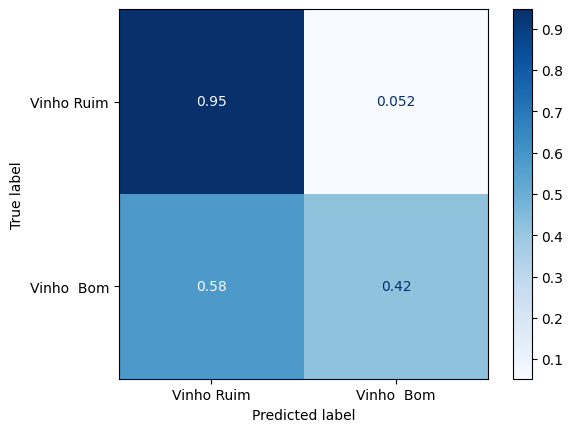

In [40]:
#Matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model_xgb, x_test, y_test, cmap='Blues', normalize='true', display_labels=['Vinho Ruim', 'Vinho  Bom'])

A Matriz de confusão indicou que em 58% das vezes o modelo colocou que os vinhos bons são ruins. Isso é claro sinal que o modelo não está conseguindo identificar a classe minoritária.

### Curvas AUC e ROC

In [28]:
from sklearn.metrics import RocCurveDisplay

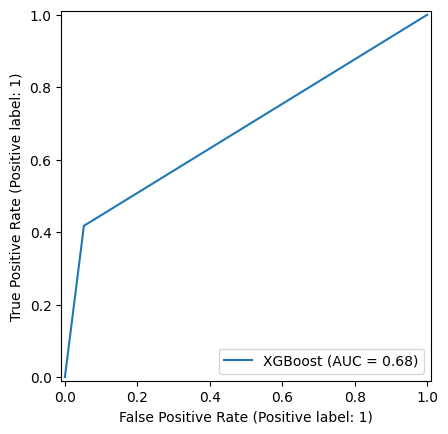

In [29]:
RocCurveDisplay.from_predictions(y_test, y_pred_xgb, name='XGBoost')

Interpretar gráfico

### Validação Cruzada (Com EarlyStop)

In [38]:
dmatrix = xgb.DMatrix(data=x_train, label=y_train) #Conversão do DF em DMatrix

params = {'objective': 'binary:logistic', 'colsample_bytree': 0.3, 'learning_rate':0.1, 'max_depth':5} #Parametros para validação cruzada
#Leaning Rate
#Max_depth
#colsample_bytree
#https://xgboost.readthedocs.io/en/stable/parameter.html

In [39]:
cv = xgb.cv(dtrain=dmatrix, params=params, nfold=3, num_boost_round=100, metrics='error', as_pandas=True, seed=SEED, early_stopping_rounds=5) #early_stopping_rounds

print(cv)

acuracia = (1 - cv['test-error-mean']).iloc[-1]

print(f'Acurácia: {acuracia:.2f}')

   train-error-mean  train-error-std  test-error-mean  test-error-std
0          0.111457         0.023471         0.111402        0.046764
Acurácia: 0.89


# Melhorando o Modelo

### Possiveis melhorias

- Base com os dados balanceados. Uma informação sobre os tipos de balanceamentos: 

https://sigmoidal.ai/estrategias-de-balanceamento-de-dados-em-machine-learning/

https://medium.com/@mate.voros1998/handling-imbalanced-datasets-with-xgboost-optimizing-model-performance-with-smart-parameter-tuning-18568c7783cf

- Hiperparametros: Random Search ou Grid Search para buscar os melhores valores para o modelo.
